# Hands tracking in a video sequence using the Kalman filter

The goal of this project is to demonstrate the use of the Kalman filter for tracking hands positions in a video sequence. Hands were chosen because their motion is usually dynamic and less regular, which makes them a suitable example for showing prediction, correction, smoothing, and uncertainty estimation.

The output of a video detector cannot be considered the exact position of the object. Detection can be affected by lighting, hand orientation, partial occlusion, camera noise, or small changes in the detected landmarks. Therefore, the measured points are regarded as noisy observations of the true position. The role of the Kalman filter is to combine these measurements with a simple motion model and obtain a state estimate that is more stable than the measurements themselves.

The system state is defined as a four-dimensional vector containing the position and velocity of one hand. The detector provides only the measured position, whereas the velocity is a hidden variable estimated by the filter.

This notebook is divided into two parts. First, the filter is validated on simulated data, where the real state of the system is known. This allows us to compare the true trajectory, noisy measurements, and the estimate obtained by the filter. Then, the same procedure is applied to real hand measurements from the detector stored in the file `tracking_data.csv`. With real data, the actual position is unknown, so the evaluation focuses primarily on the estimated trajectory, interval uncertainty, and measurement residuals.

---

## 1. Description of the system

### 1.1 Observed objects

The project focuses on hands captured by a webcam. The accompanying detector script `hands_tracker.py` detects at most two hands and stores them under the labels:

- `hand_left`,
- `hand_right`.

Each hand is represented by one measured point. In the detector, this point is computed as the average position of the detected MediaPipe hand landmarks. The full hand shape is not modeled in the Kalman filter. For the purposes of this project, the important input is the time sequence of measured hand centers, because this is sufficient for demonstrating filtering and prediction in a two-dimensional image plane.

### 1.2 Measurements from the video

Measurements obtained from video are subject to several types of uncertainty. The detected hand center may slightly change between frames even when the hand is almost still. The position can also be affected by hand orientation, partial occlusion, fast movement, motion blur, distance from the camera, or small variations in the detected landmarks. Additional uncertainty arises because frames are not always processed at exactly the same time interval.

In the model, this uncertainty is described as observation noise. This means that the measured hand position is not considered the exact true position, but only a noisy version of it. The Kalman filter then decides how much to trust the current measurement relative to the previous estimate and the selected measurement covariance.

### 1.3 Data format and measured variables

The detector saves measurements in the file `tracking_data.csv` in the following format:

```text
timestamp, obj_type, meas_x, meas_y, pred_x, pred_y
```

Individual columns have the following meaning:

- `timestamp` – the time when the measurement was recorded,
- `obj_type` – type of the tracked hand, either `hand_left` or `hand_right`,
- `meas_x`, `meas_y` – measured hand-center position in the frame in pixels,
- `pred_x`, `pred_y` – prediction from the detector, if available.

In the notebook we mainly use the columns `timestamp`, `obj_type`, `meas_x`, and `meas_y`. The columns `pred_x` and `pred_y` are not necessary for the main evaluation because the Kalman filter is implemented again directly in this notebook. This makes it clear which state model is used, how the covariance matrices are set up, and how the interval estimates are calculated.

Let us now describe the variables and metrics more in detail:

1. **Measured position**  
   The values `meas_x` and `meas_y` represent the hand position obtained from the detector. They are not the exact true position, but noisy observations. For real video data, these values are the input to the Kalman filter.

2. **Estimated state**  
   The Kalman filter does not estimate only the position, but the whole state vector

   $X_k = (x_k, y_k, v_{x,k}, v_{y,k})^T,$
   
   which means that the velocities `v_x` and `v_y` are estimated from the measured coordinates `meas_x` and `meas_y`.

3. **Measurement residual**  
   The measurement residual represents the difference between the actual measured position and the predicted measurement:

   $r_k = y_k - H\mu_k^-.$

   Large residual values indicate that the new measurement differs significantly from the model prediction. This can occur, for example, during fast hand movement, partial occlusion, or a temporary detection inaccuracy.

4. **Covariance matrix of the estimate**  
   The covariance matrix $\Sigma_k$ describes the uncertainty of the estimate. We mainly use its diagonal elements because they correspond to the variances of the individual state components. For example, the value $\Sigma_{x,x}$ represents the uncertainty in the estimate of the $x$ coordinate.

5. **95% interval estimates**  
   For each tracked state component, we plot the interval

   $\mu_{k,i} \pm 1.96\sqrt{\Sigma_{k,i,i}}.$

   This interval shows how precise the estimate of the given component is. A narrow interval means higher certainty, while a wide interval means greater uncertainty.

6. **RMSE for simulated data**  
   For simulated data, the true state is known, so we can compute the estimation error using the RMSE metric:

   $\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{k=1}^{n}(x_k - \hat{x}_k)^2}.$

   RMSE is computed separately for the $x$ and $y$ coordinates. A lower value means a more accurate estimate. This metric is used only for simulated data because, for real video, the exact true position of the hand is unknown.

7. **Multi-step prediction**  
   In the prediction part, we observe where the hand should move several steps into the future according to the model, without using additional measurements. This part shows the difference between filtering, which continuously uses new measurements, and prediction alone, which works only with the motion model.

Together, these variables and metrics show not only the hand trajectory, but also the quality and uncertainty of the estimate. This is important because the goal is not only to draw a smoother curve, but to show how the Kalman filter combines the motion model, noisy measurements, and estimation uncertainty.

## 2. Mathematical model

### 2.1 State vector

For each tracked object, we use the state vector

$$
X_k = \begin{pmatrix}x_k \ y_k \ v_{x,k} \ v_{y,k}\end{pmatrix}.
$$

The components $x_k$ and $y_k$ represent the position of the object in pixels at time $k$. The components $v_{x,k}$ and $v_{y,k}$ represent the velocity of the object in pixels per second. The velocity is not directly observed by the detector, but it is estimated by the filter from changes in position over time.

This state vector is suitable for several reasons. It is simple enough for a linear Kalman filter, but it still contains more information than position alone. By including velocity, the filter can not only smooth the measurements, but also predict the future position of the object when a new measurement is not yet available.

### 2.2 Continuous constant-velocity model

As the basic motion model, we use a constant-velocity model. In continuous time, it can be written as

$$
\frac{dx}{dt}=v_x,\qquad \frac{dy}{dt}=v_y,\qquad \frac{dv_x}{dt}=0,\qquad \frac{dv_y}{dt}=0.
$$

The model says that position changes according to the current velocity, while the velocity remains approximately constant between two time moments. In a real video, this assumption is of course not perfectly true. A hand can accelerate, slow down, or change direction. These inaccuracies are included in the process noise.

### 2.3 Discretization of the model

Since video provides measurements frame by frame, we use discrete time. Let $\Delta t_k$ denote the time difference between points $k-1$ and $k$. After discretization, we obtain the state equation

$$
X_k = A_k X_{k-1} + W_k,
$$

where

$$
A_k = \begin{pmatrix}
1&0&\Delta t_k&0\\
0&1&0&\Delta t_k\\
0&0&1&0\\
0&0&0&1
\end{pmatrix}.
$$

The first row of the matrix says that the new $x$ coordinate is equal to the previous coordinate plus the velocity in the $x$ direction multiplied by the time step. The second row has the same meaning for the $y$ coordinate. The third and fourth rows express the assumption that, without noise, the velocity does not change between two steps.

### 2.4 Process noise

The process noise $W_k$ describes uncertainty in the motion model:

$$
W_k \sim \mathcal{N}(0,Q_k).
$$

We use the standard form of the covariance matrix corresponding to random acceleration:

$$
Q_k = \sigma_a^2
\begin{pmatrix}
\frac{\Delta t_k^4}{4} & 0 & \frac{\Delta t_k^3}{2} & 0\\
0 & \frac{\Delta t_k^4}{4} & 0 & \frac{\Delta t_k^3}{2}\\
\frac{\Delta t_k^3}{2} & 0 & \Delta t_k^2 & 0\\
0 & \frac{\Delta t_k^3}{2} & 0 & \Delta t_k^2
\end{pmatrix}.
$$

The parameter $\sigma_a$ determines how large changes in velocity the model allows. A small value means that we strongly trust the constant-velocity model. A large value means that the motion may be more irregular and that the filter should react more quickly to changes in direction or speed.

### 2.5 Observation model

The detector measures only the position of the hand:

$$
Y_k = \begin{pmatrix}x_k^{\mathrm{meas}} \\ y_k^{\mathrm{meas}}\end{pmatrix}.
$$

The observation equation has the form

$$
Y_k = H X_k + V_k,
$$

where

$$
H =
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0
\end{pmatrix},
\qquad
V_k \sim \mathcal{N}(0,R),
\qquad
R =
\begin{pmatrix}
\sigma_z^2 & 0 \\
0 & \sigma_z^2
\end{pmatrix}.
$$

The matrix $H$ selects only the first two components of the state vector, that is, the position. Velocity does not appear in the observation because the detector does not measure it directly. The parameter $\sigma_z$ represents the standard deviation of the measurement error in pixels. A larger value of $\sigma_z$ means that the measurements are considered less accurate.

### 2.6 Initial estimate

The filter has to be initialized with an initial state estimate and an initial covariance matrix. In the implementation, the first available measurement is used as the initial position. The initial velocity is set to zero because, at the beginning, there is not enough information about the motion yet.

The initial uncertainty of the velocity is chosen to be relatively large. This allows the filter to adapt quickly to the actual motion during the first few steps. The initial position is taken from the first measurement, but still with some uncertainty, because even the first measurement does not have to be exact.

## 3. Kalman filter

The Kalman filter works recursively. This means that, at each step, it uses only the previous state estimate, the previous covariance matrix, and the current measurement. It is not necessary to process the entire measurement history again. Each step consists of two parts: **prediction** and **correction**.

### 3.1 Prediction step

In the prediction step, the filter first estimates where the object should be according to the motion model, before using the new measurement:

$$
\mu_k^- = A_k\mu_{k-1},
$$

$$
\Sigma_k^- = A_k\Sigma_{k-1}A_k^T + Q_k.
$$

The vector $\mu_k^-$ is the predicted mean of the state. The matrix $\Sigma_k^-$ is the predicted covariance matrix. Adding the matrix $Q_k$ increases the uncertainty after prediction, because the motion model is not perfectly accurate.

### 3.2 Correction step

In the correction step, the prediction is corrected using the current measurement. First, the covariance of the measurement residual is computed:

$$
S_k = H\Sigma_k^-H^T + R,
$$

then the Kalman gain:

$$
K_k = \Sigma_k^-H^TS_k^{-1},
$$

and finally the updated mean:

$$
\mu_k = \mu_k^- + K_k(Y_k-H\mu_k^-).
$$

The expression $Y_k-H\mu_k^-$ is called the measurement residual. It is the difference between the actually measured position and the position expected by the filter according to the prediction. If the measurement residual is large, the measurement differs significantly from the model prediction.

The covariance matrix is updated using the Joseph form:

$$
\Sigma_k = (I-K_kH)\Sigma_k^-(I-K_kH)^T + K_kRK_k^T.
$$

This form is numerically stable and helps preserve the symmetry and positive semidefiniteness of the covariance matrix.

### 3.3 Meaning of the Kalman gain

The Kalman gain determines the trade-off between the model and the measurement. If the measurement is considered very accurate, the filter moves closer to it. If the measurement is considered very noisy, the filter relies more on the prediction from the motion model.

In practice, this means that for a small value of $\sigma_z$, the estimate follows the detected points more closely. For a larger value of $\sigma_z$, the estimate is smoother, but it may react more slowly to sudden changes in motion.

### 3.4 95% intervals

In addition to the point estimate, we also want to show the uncertainty of the estimate. For each state component, we use the marginal 95% interval

$$
\mu_{k,i} \pm 1.96\sqrt{\Sigma_{k,ii}}.
$$

This interval is computed separately for individual components of the state vector. It is therefore not a joint multidimensional region, but a simple and clear visualization of uncertainty for position and velocity over time.

## 4. Python implementation

This section defines the functions needed to compute the Kalman filter. 

First, the matrices $A_k$ and $Q_k$ are defined. Both depend on the time step $\Delta t_k$. Then the main function `run_kalman_filter` follows. This function goes through the sequence of measurements and, at each step, stores the mean estimate, covariance matrix, prediction, and measurement residual. Helper functions for computing RMSE and for plotting graphs with 95% intervals are also prepared.

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [115]:
def A_matrix(dt):
    return np.array([
        [1.0, 0.0, dt, 0.0],
        [0.0, 1.0, 0.0, dt],
        [0.0, 0.0, 1.0, 0.0],
        [0.0, 0.0, 0.0, 1.0],
    ], dtype=float)


def Q_matrix(dt, sigma_a):
    return sigma_a**2 * np.array([
        [dt**4/4, 0.0, dt**3/2, 0.0],
        [0.0, dt**4/4, 0.0, dt**3/2],
        [dt**3/2, 0.0, dt**2, 0.0],
        [0.0, dt**3/2, 0.0, dt**2],
    ], dtype=float)


H = np.array([
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0]
    ], dtype=float)


def R_matrix(sigma_z):
    return np.diag([sigma_z**2, sigma_z**2]).astype(float)

In [116]:
def run_kalman_filter(times, measurements, sigma_a=80.0, sigma_z=20.0,
                      initial_position_std=50.0, initial_velocity_std=500.0):
    times = np.asarray(times, dtype=float)
    measurements = np.asarray(measurements, dtype=float)

    if len(times) != len(measurements):
        raise ValueError("Times and measurements must have the same length")
    if len(times) == 0:
        raise ValueError("Empty input")

    # find the first valid measurement
    valid0 = np.where(np.isfinite(measurements).all(axis=1))[0]
    if len(valid0) == 0:
        raise ValueError("No valid measurement")

    # initialization of the state estimate
    first = valid0[0]
    mu = np.array([
        measurements[first, 0],
        measurements[first, 1],
        0.0,
        0.0
    ], dtype=float)

    # initialization of the uncertainty
    Sigma = np.diag([
        initial_position_std**2,
        initial_position_std**2,
        initial_velocity_std**2,
        initial_velocity_std**2
    ]).astype(float)

    # fixed matrices and storage
    # R ... covariance matrix of the measurement noise
    # I ... used in the covariance update
    R = R_matrix(sigma_z)
    I = np.eye(4)

    rows = []
    covariances = []
    previous_time = times[first]

    # main Kalman filter loop
    for k in range(first, len(times)):
        t = times[k]
        z = measurements[k]

        # compute the time step
        dt = max(float(t - previous_time), 1e-6)
        previous_time = t

        A = A_matrix(dt)
        Q = Q_matrix(dt, sigma_a)

        # prediction step
        mu_pred = A @ mu
        Sigma_pred = A @ Sigma @ A.T + Q

        # default values used when the measurement is missing
        measurement_residual = np.array([np.nan, np.nan])

        # correction step
        if np.isfinite(z).all():
            measurement_residual = z - H @ mu_pred

            S = H @ Sigma_pred @ H.T + R

            # Kalman gain
            K = Sigma_pred @ H.T @ np.linalg.inv(S)

            # corrected state estimate
            mu = mu_pred + K @ measurement_residual

            # corrected covariance estimate
            Sigma = (I - K @ H) @ Sigma_pred @ (I - K @ H).T + K @ R @ K.T

        else:
            mu = mu_pred
            Sigma = Sigma_pred

        std = np.sqrt(np.maximum(np.diag(Sigma), 0.0))

        rows.append({
            "k": k,
            "time": t,
            "dt": dt,

            # raw measurement
            "meas_x": z[0] if np.isfinite(z[0]) else np.nan,
            "meas_y": z[1] if np.isfinite(z[1]) else np.nan,

            # one-step prediction before correction
            "pred_x": mu_pred[0],
            "pred_y": mu_pred[1],

            # filtered state estimate after correction
            "x": mu[0],
            "y": mu[1],
            "vx": mu[2],
            "vy": mu[3],

            # marginal standard deviations of the state variables
            "std_x": std[0],
            "std_y": std[1],
            "std_vx": std[2],
            "std_vy": std[3],

            # residual diagnostics
            "residual_x": measurement_residual[0],
            "residual_y": measurement_residual[1],
        })

        covariances.append(Sigma.copy())

    return pd.DataFrame(rows), np.array(covariances)

In [117]:
def rmse(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return float(np.sqrt(np.nanmean((a - b) ** 2)))


def add_confidence_bounds(df):
    out = df.copy()
    for col in ["x", "y", "vx", "vy"]:
        out[f"{col}_lower95"] = out[col] - 1.96 * out[f"std_{col}"]
        out[f"{col}_upper95"] = out[col] + 1.96 * out[f"std_{col}"]
    return out


def plot_xy_trajectory(df, title, true_df=None):
    plt.figure(figsize=(10, 6))

    if true_df is not None:
        plt.plot(true_df["true_x"], true_df["true_y"], label="true trajectory")

    plt.scatter(df["meas_x"], df["meas_y"], s=14, alpha=0.45, label="measurement")
    plt.plot(df["x"], df["y"], linewidth=2, label="KF estimate")
    plt.xlabel("x [px]")
    plt.ylabel("y [px]")
    plt.title(title)
    plt.legend()
    plt.gca().invert_yaxis()
    plt.show()


def plot_state_with_interval(df, coord, title, true_values=None):
    lower = df[coord] - 1.96 * df[f"std_{coord}"]
    upper = df[coord] + 1.96 * df[f"std_{coord}"]
    plt.figure(figsize=(10, 6))

    if true_values is not None:
        plt.plot(df["time"], true_values, label="true state")

    if coord in ["x", "y"]:
        plt.scatter(df["time"], df[f"meas_{coord}"], s=12, alpha=0.35, label="measurement")

    plt.plot(df["time"], df[coord], linewidth=2, label="mean estimate")
    plt.fill_between(df["time"], lower, upper, alpha=0.20, label="95% interval")
    plt.xlabel("time [s]")
    plt.ylabel(coord)
    plt.title(title)
    plt.legend()
    plt.show()

## 5. Simulated benchmark

The simulated part is the most important part for verifying whether the filter works correctly. In a real video, the exact true position of a hand is usually unknown. We only see the detector output, which can itself contain errors. In a simulation, on the other hand, the true state is known because we generate it ourselves.

This makes it possible to directly compare three different metrics:

- the true trajectory of the hand,
- noisy measurements that imitate the detector output,
- the estimate obtained by the Kalman filter.

The simulation is designed so that the motion is not perfectly constant. Changing acceleration is added to the true trajectory, so the filter works with a slightly simplified model. This corresponds to a real situation: the model never describes reality perfectly, but it should be good enough to produce a stable estimate.

In [118]:
def simulate_motion(n=220, dt=0.05, measurement_sigma=25.0, seed=7):
    rng = np.random.default_rng(seed)
    times = np.arange(n) * dt
    true = np.zeros((n, 4), dtype=float)
    true[0] = [250.0, 360.0, 120.0, -35.0]

    for k in range(1, n):
        t = times[k]
        ax = 70.0 * np.sin(1.3 * t) + rng.normal(0.0, 12.0)
        ay = 55.0 * np.cos(0.9 * t) + rng.normal(0.0, 12.0)
        true[k, 2] = true[k-1, 2] + ax * dt
        true[k, 3] = true[k-1, 3] + ay * dt
        true[k, 0] = true[k-1, 0] + true[k, 2] * dt
        true[k, 1] = true[k-1, 1] + true[k, 3] * dt

    measurements = true[:, :2] + rng.normal(0.0, measurement_sigma, size=(n, 2))
    return pd.DataFrame({
        "time": times,
        "true_x": true[:, 0], "true_y": true[:, 1],
        "true_vx": true[:, 2], "true_vy": true[:, 3],
        "meas_x": measurements[:, 0], "meas_y": measurements[:, 1],
    })

sim_df = simulate_motion()
sim_df.head()

,time,true_x,true_y,true_vx,true_vy,meas_x,meas_y
0,0.00,250.000000,360.000000,120.000000,-35.000000,211.765707,360.087704
1,0.05,256.011404,358.396323,120.228078,-32.073537,239.762499,333.967687
2,0.10,262.037270,356.902872,120.517315,-29.869022,283.373211,343.948630
3,0.15,268.083404,355.515921,120.922695,-27.739031,305.540946,336.019936
4,0.20,274.176333,354.304454,121.858563,-24.229332,283.838882,348.622379


### 5.1 Trajectory simulation

In this part, an artificial trajectory of an object in the image plane is created. The true state contains the coordinates $x$, $y$ and the velocities $v_x$, $v_y$. Measurements are then generated from the true position by adding noise.

The measurements therefore represent a situation where the detector returns the position of the object in each frame, but this position randomly differs from the true position. The graph below shows the difference between the smooth true trajectory and the scattered measured points.

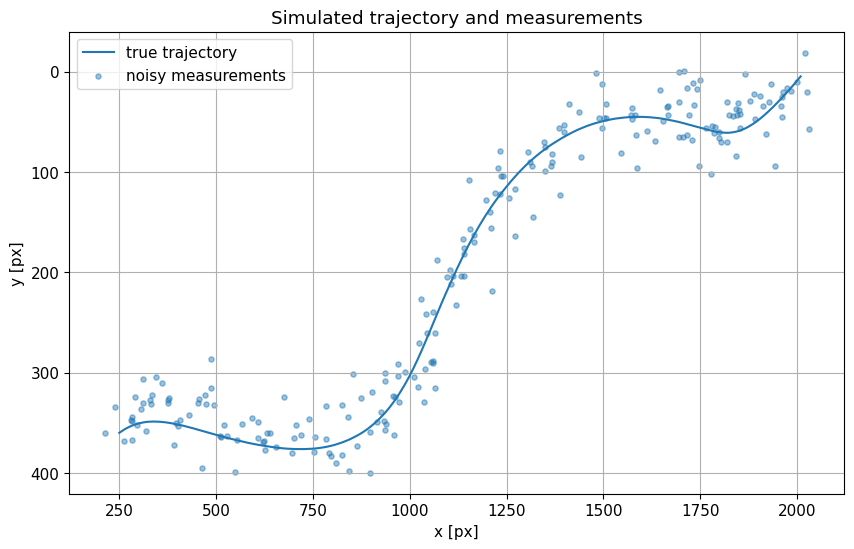

In [119]:
plt.figure(figsize=(10, 6))
plt.plot(sim_df["true_x"], sim_df["true_y"], label="true trajectory")
plt.scatter(sim_df["meas_x"], sim_df["meas_y"], s=14, alpha=0.45, label="noisy measurements")
plt.xlabel("x [px]")
plt.ylabel("y [px]")
plt.title("Simulated trajectory and measurements")
plt.legend()
plt.gca().invert_yaxis()
plt.show()

### 5.2 Filtering simulated data

The Kalman filter is now applied to the noisy measurements. At each step, the filter first predicts the state according to the constant-velocity model and then corrects this prediction using the current measurement.

The result is an estimated trajectory that should be smoother than the measurements themselves, while still following the real motion of the object. In addition to the mean estimate, 95% intervals are plotted for the $x$ and $y$ coordinates to show the uncertainty of the estimate at individual times.

In [120]:
sigma_z_sim = 25.0
sigma_a_sim = 120.0

sim_filter, sim_covs = run_kalman_filter(
    sim_df["time"].to_numpy(),
    sim_df[["meas_x", "meas_y"]].to_numpy(),
    sigma_a=sigma_a_sim,
    sigma_z=sigma_z_sim
)

sim_filter = add_confidence_bounds(sim_filter)
sim_filter.head()

,k,time,dt,meas_x,meas_y,pred_x,pred_y,x,y,vx,...,residual_x,residual_y,x_lower95,x_upper95,y_lower95,y_upper95,vx_lower95,vx_upper95,vy_lower95,vy_upper95
0,0,0.00,0.000001,211.765707,360.087704,211.765707,360.087704,211.765707,360.087704,0.000000,...,0.000000,0.000000,167.938775,255.592640,316.260771,403.914636,-980.000000,980.000000,-980.000000,980.000000
1,1,0.05,0.050000,239.762499,333.967687,211.765707,360.087704,229.763802,343.296118,199.989139,...,27.996792,-26.120017,190.476228,269.051376,304.008544,382.583692,-585.817167,985.795445,-972.389100,599.223512
2,2,0.10,0.050000,283.373211,343.948630,239.763259,333.966978,268.837432,340.621612,490.759613,...,43.609952,9.981652,228.828500,308.846365,300.612680,380.630545,-54.579547,1036.098773,-665.369036,425.309284
3,3,0.15,0.050000,305.540946,336.019936,293.375413,334.620118,300.938251,335.490331,549.959987,...,12.165533,1.399818,262.303964,339.572538,296.856044,374.124618,166.222695,933.697279,-496.955322,270.519262
4,4,0.20,0.050000,283.838882,348.622379,328.436250,329.829429,303.557862,340.312969,393.505698,...,-44.597368,18.792950,266.960264,340.155461,303.715371,376.910567,109.670704,677.340692,-331.124524,236.545464


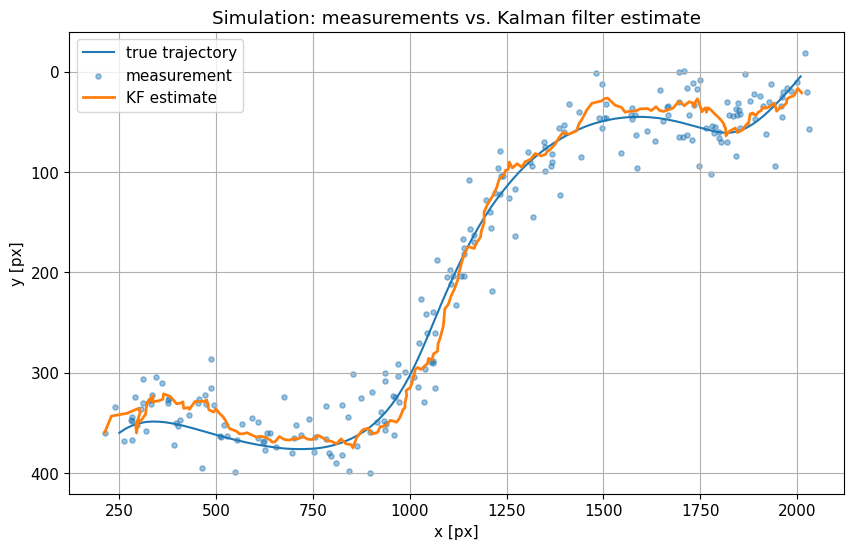

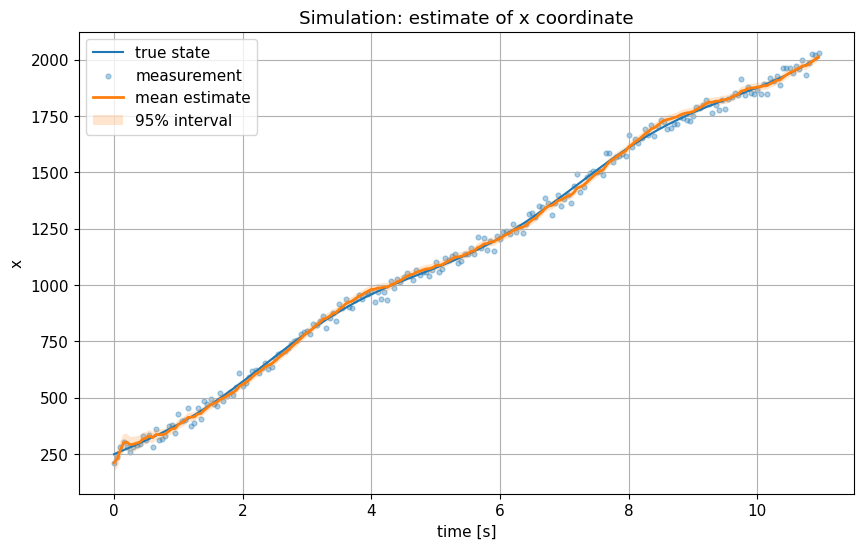

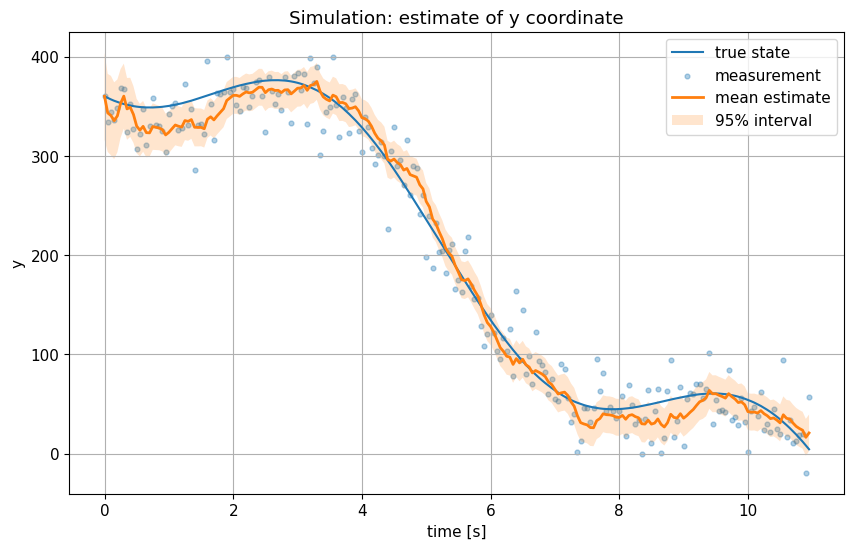

In [121]:
plot_xy_trajectory(sim_filter, "Simulation: measurements vs. Kalman filter estimate", true_df=sim_df)
plot_state_with_interval(sim_filter, "x",
                         "Simulation: estimate of x coordinate",
                         true_values=sim_df.loc[sim_filter["k"], "true_x"].to_numpy())

plot_state_with_interval(sim_filter, "y",
                         "Simulation: estimate of y coordinate",
                         true_values=sim_df.loc[sim_filter["k"], "true_y"].to_numpy())

### 5.3 Velocity estimate

An important property of the chosen model is that the filter also estimates the velocities $v_x$ and $v_y$. These variables are not measured directly because the detector provides only position. Nevertheless, the filter can estimate them indirectly from the time sequence of positions.

The velocity graphs are therefore useful for demonstrating the hidden components of the state. They show that the Kalman filter is not only used to smooth measured points, but actually reconstructs the whole state vector.

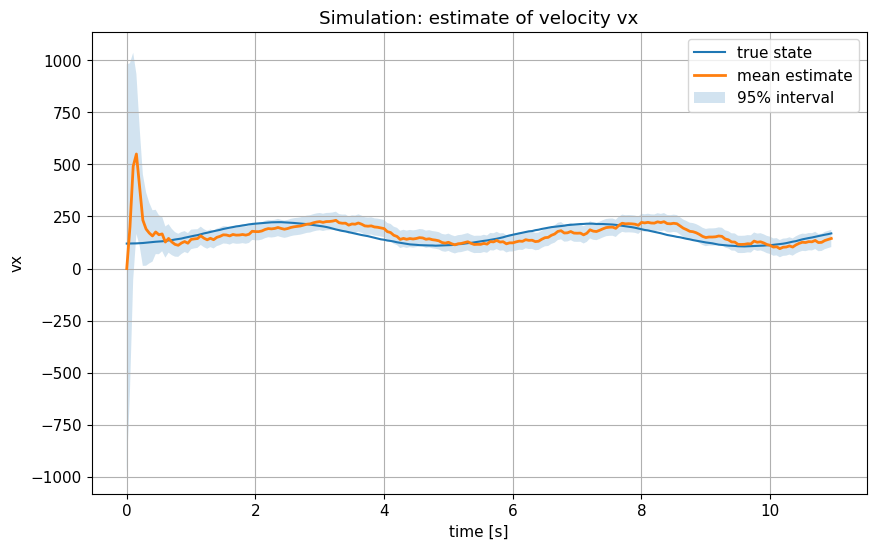

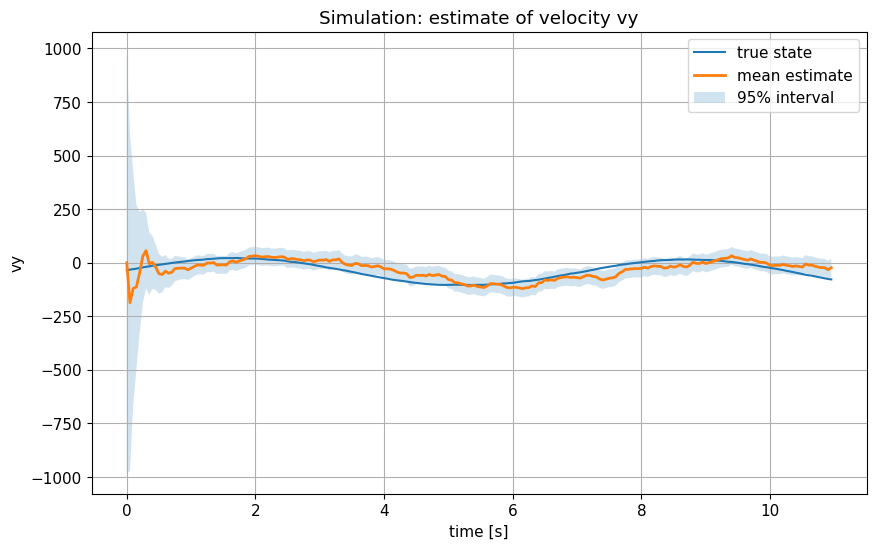

In [122]:
plot_state_with_interval(sim_filter, "vx", 
                         "Simulation: estimate of velocity vx",
                         true_values=sim_df.loc[sim_filter["k"], "true_vx"].to_numpy())

plot_state_with_interval(sim_filter, "vy",
                         "Simulation: estimate of velocity vy",
                         true_values=sim_df.loc[sim_filter["k"], "true_vy"].to_numpy())

### 5.4 Accuracy evaluation

For quantitative evaluation, we use RMSE, that is, the root mean square error. We compare the error of the measurements themselves and the error of the Kalman filter estimate against the known true position.

If the filter works correctly, the error of the filtered estimate should be smaller than the error of the measurements themselves. However, the filter does not have to be closer to the truth at every single time instant. The overall trend is more important: the filter should suppress random fluctuations and use information about the motion dynamics.

In [123]:
truth_x = sim_df.loc[sim_filter["k"], "true_x"].to_numpy()
truth_y = sim_df.loc[sim_filter["k"], "true_y"].to_numpy()

coverage_x = np.mean((truth_x >= sim_filter["x_lower95"]) & (truth_x <= sim_filter["x_upper95"]))
coverage_y = np.mean((truth_y >= sim_filter["y_lower95"]) & (truth_y <= sim_filter["y_upper95"]))

summary_sim = pd.DataFrame({
    "quantity": ["x", "y"],
    "RMSE measurement [px]": [rmse(sim_filter["meas_x"], truth_x), rmse(sim_filter["meas_y"], truth_y)],
    "RMSE KF estimate [px]": [rmse(sim_filter["x"], truth_x), rmse(sim_filter["y"], truth_y)],
    "95% interval coverage": [coverage_x, coverage_y],
})
summary_sim

,quantity,RMSE measurement [px],RMSE KF estimate [px],95% interval coverage
0,x,23.936394,11.834460,0.913636
1,y,24.415399,13.301396,0.818182


The result shows that the Kalman filter reduces the error compared with the measurements alone. This is expected because the filter does not copy each measurement independently, but combines the measurements with the motion model and the previous state estimate.

At the same time, the uncertainty intervals are not just an additional visual element. They express how certain the filter is about the estimate of individual components at a given time. After the initial phase, the uncertainty usually decreases because the filter has already received several measurements and has estimated the object velocity more accurately. If the measurements were less accurate or if the process noise were larger, the intervals would be wider.

## 6. Real data from the hand detector

This section uses the file `tracking_data.csv`, which can be created by the accompanying script `hands_tracker.py`. The detector records the measured centers of the left and right hand using MediaPipe hand landmarker and stores them under the labels `hand_left` and `hand_right`.

Real data are more difficult than simulation. In simulation, the true state is known, while in video we only have the detector output, as previously mentioned. Therefore, the error with respect to the truth cannot be computed exactly here. Instead, we observe whether the filter creates a smoother trajectory, whether it can bridge small fluctuations in the measurements, and whether the estimated uncertainty corresponds to the behavior of the data.

In [124]:
def timestamp_to_seconds(series):
    parsed = pd.to_datetime(series, format="%H:%M:%S.%f", errors="coerce")

    if parsed.isna().any():
        parsed = pd.to_datetime(series, errors="coerce")

    if parsed.isna().any():
        raise ValueError("Some timestamps could not be converted")

    seconds = (parsed.dt.hour * 3600 + parsed.dt.minute * 60 + parsed.dt.second + parsed.dt.microsecond / 1e6).to_numpy(dtype=float)
    corrected = seconds.copy()

    for i in range(1, len(corrected)):
        if corrected[i] < corrected[i - 1]:
            corrected[i:] += 24 * 3600

    return corrected - corrected[0]

expected_objects = ["hand_left", "hand_right"]

csv_path = Path("tracking_data.csv")

if csv_path.exists():
    df_raw = pd.read_csv(csv_path)
    df_raw["time"] = timestamp_to_seconds(df_raw["timestamp"])
    objects = [obj for obj in expected_objects if obj in set(df_raw["obj_type"])]
    df_raw = df_raw[df_raw["obj_type"].isin(objects)].copy()

    print("Loaded file:", csv_path)
    print("Number of hand-measurement rows:", len(df_raw))
    print("Detected hand labels:", objects)

    display(df_raw.head())
else:
    df_raw = None
    objects = []
    print("File tracking_data.csv was not found. The real-data part will be skipped.")

Loaded file: tracking_data.csv
Number of hand-measurement rows: 860
Detected hand labels: ['hand_left', 'hand_right']


,timestamp,obj_type,meas_x,meas_y,pred_x,pred_y,time
0,19:01:27.470824,hand_right,765,342,NaN,NaN,0.000000
1,19:01:27.586032,hand_right,1038,436,765.0,342.0,0.115208
2,19:01:27.705882,hand_left,552,386,NaN,NaN,0.235058
3,19:01:27.705882,hand_right,973,428,1172.0,482.0,0.235058
4,19:01:27.825700,hand_left,478,400,552.0,386.0,0.354876


### 6.1 Example of measured hand trajectories

First, the raw hand measurements from the detector are displayed. Each detected hand is plotted separately. This visualization is useful even before applying the filter because it makes it possible to quickly assess the quality of the input data.

If the trajectory contains large jumps, missing detections, or long dropouts, a perfectly smooth result cannot be expected from the filter alone. The Kalman filter can suppress noise, but it cannot fully correct systematically wrong measurements or object swaps.

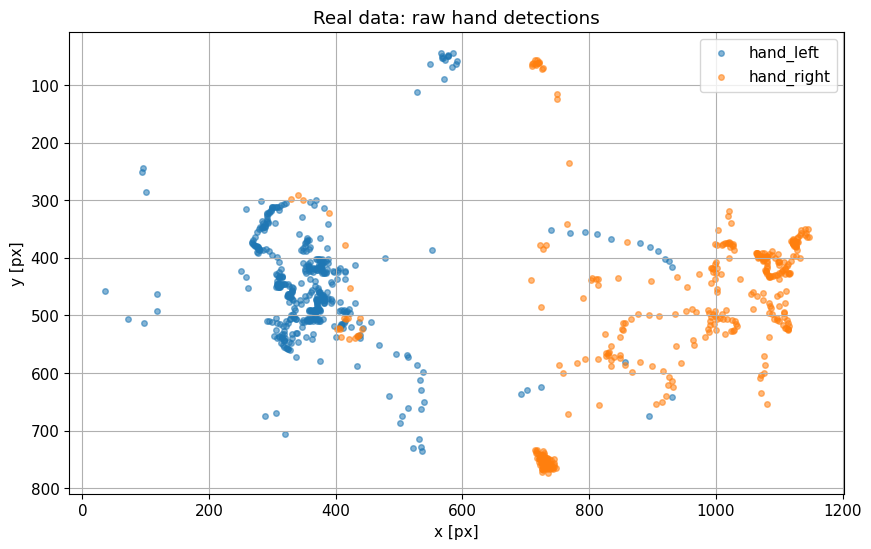

In [125]:
if df_raw is not None and objects:
    plt.figure(figsize=(10, 6))

    for obj in objects:
        part = df_raw[df_raw["obj_type"] == obj]
        plt.scatter(part["meas_x"], part["meas_y"], s=16, alpha=0.55, label=obj)

    plt.xlabel("x [px]")
    plt.ylabel("y [px]")
    plt.title("Real data: raw hand detections")
    plt.legend()
    plt.gca().invert_yaxis()
    plt.show()
elif df_raw is not None:
    print("The file was loaded, but it does not contain hand_left or hand_right measurements.")
else:
    print("Real data are not available.")

### 6.2 Filtering real hand measurements

The same Kalman filter as in the simulated part is now applied to the measurements of individual hands. The filter is run separately for `hand_left` and `hand_right`, because each hand has its own trajectory.

The output is an estimate of position and velocity over time. In the trajectory plots, the original measured points can be compared with the filtered estimate. The estimate should be smoother than the measurements themselves, but it should not completely ignore the actual motion of the hand.

In [126]:
real_results = {}
real_covs = {}

if df_raw is not None and objects:
    sigma_z_real = 35.0
    sigma_a_real = 250.0

    for obj in objects:
        part = df_raw[df_raw["obj_type"] == obj].sort_values("time")
        if len(part) < 3:
            print(f"Object {obj}: too few measurements, skipped.")
            continue

        result, covs = run_kalman_filter(
            part["time"].to_numpy(),
            part[["meas_x", "meas_y"]].to_numpy(),
            sigma_a=sigma_a_real,
            sigma_z=sigma_z_real,
        )
        result = add_confidence_bounds(result)
        result["obj_type"] = obj
        real_results[obj] = result
        real_covs[obj] = covs
    print("Filtered hand trajectories:", list(real_results.keys()))
elif df_raw is not None:
    print("No hand_left or hand_right measurements are available.")
else:
    print("Real data are not available.")

Filtered hand trajectories: ['hand_left', 'hand_right']


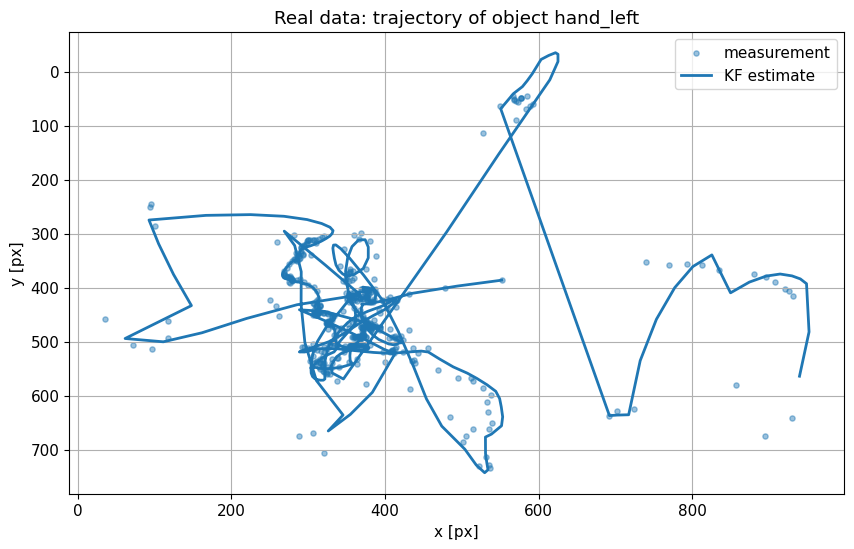

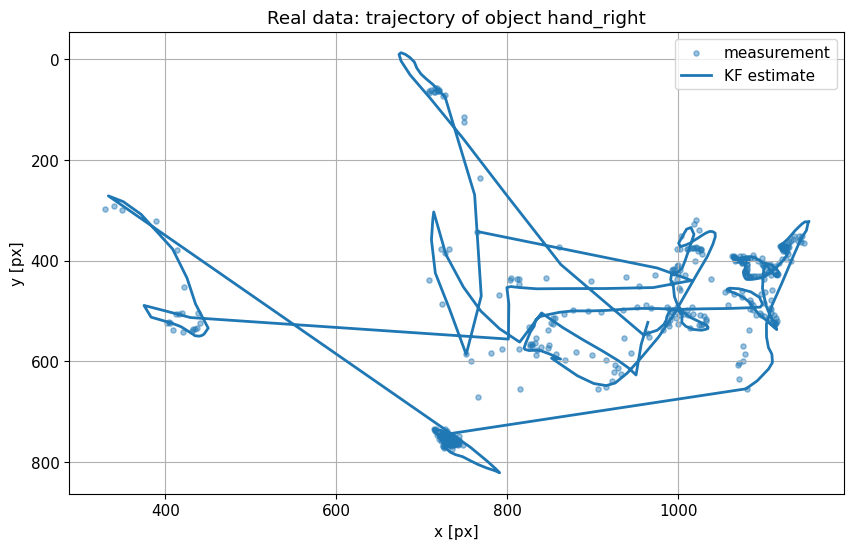

In [127]:
for obj, result in real_results.items():
    plot_xy_trajectory(result, f"Real data: trajectory of object {obj}")

### 6.3 Interval estimates for real data

For real hand data, we display 95% intervals for individual state components. These intervals do not mean that the true position is certainly inside the interval, because the true state is unknown and the model is only an approximation. They serve as an internal estimate of the filter uncertainty.

The interval width mainly depends on the settings of process noise and measurement noise. If the filter trusts the measurements too much, the intervals may be narrow, but the estimate may copy detector noise. If the filter trusts the measurements less, the intervals may be wider and the estimate smoother.

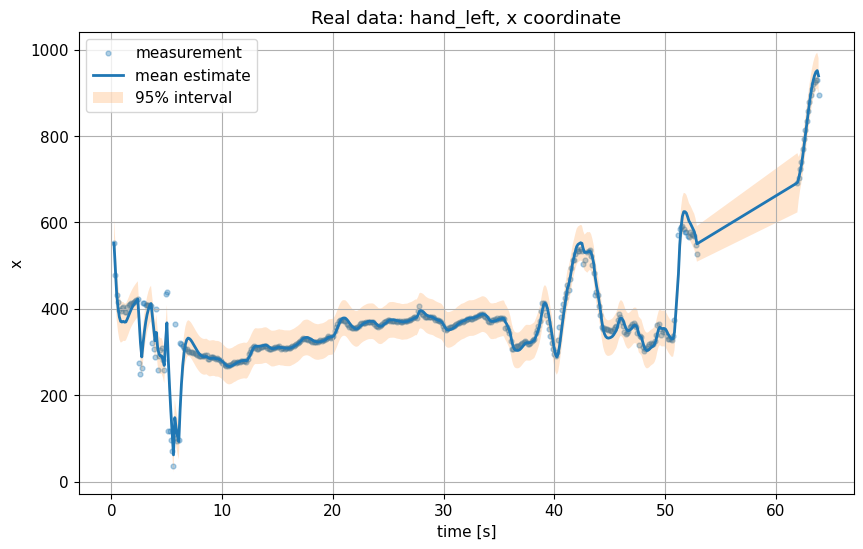

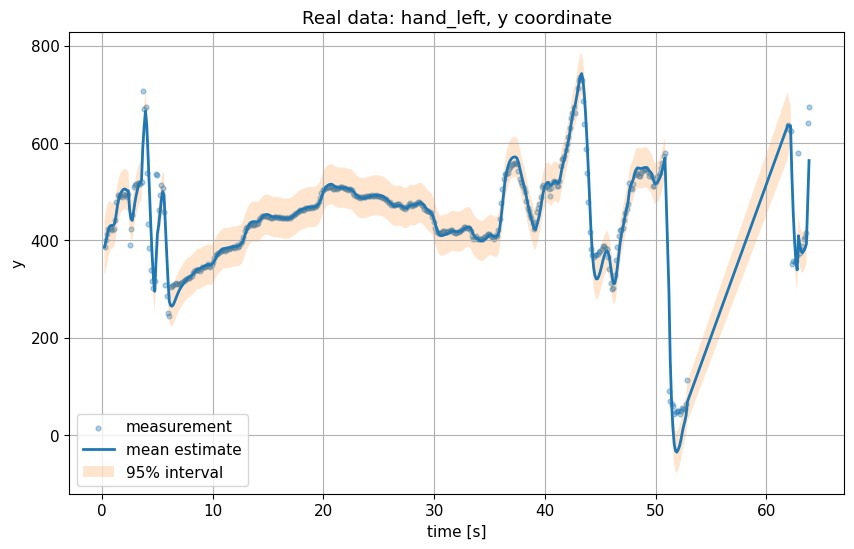

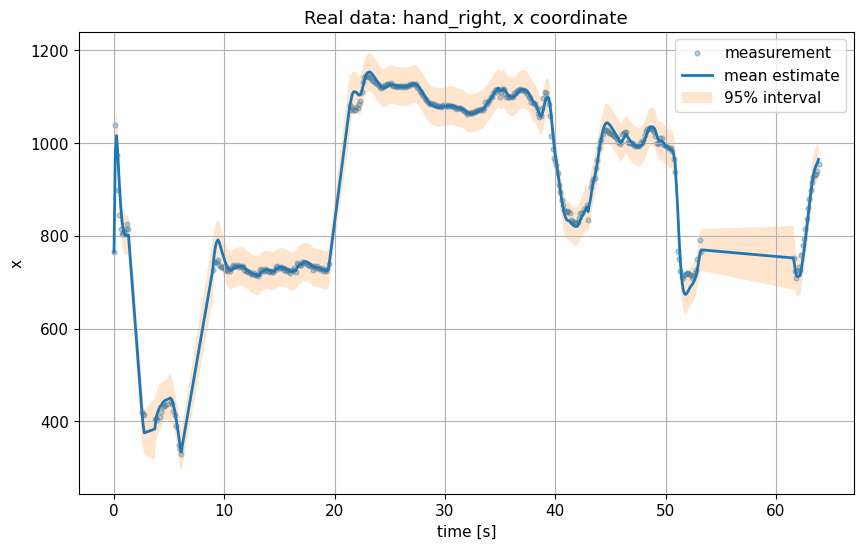

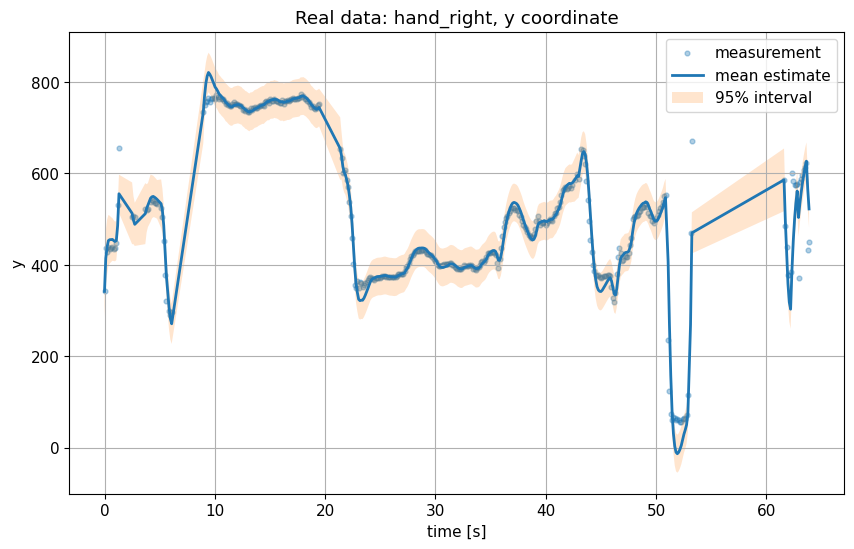

In [128]:
for obj, result in real_results.items():
    plot_state_with_interval(result, "x", f"Real data: {obj}, x coordinate")
    plot_state_with_interval(result, "y", f"Real data: {obj}, y coordinate")

### 6.4 Measurement residual

The measurement residual is the difference between the current measurement and the predicted measurement:

$$
\nu_k = Y_k - H\mu_k^-.
$$

If its value is small, the current measurement agrees with what the filter expected based on the previous state and the motion model. If the measurement residual is large, it indicates a mismatch between the model and the measurement.

In practice, large measurement residuals may indicate, for example, a sudden change in hand motion, a temporary detection inaccuracy, or partial occlusion of the hand. Therefore, the residual plot is a useful supplement to the usual trajectory plots.

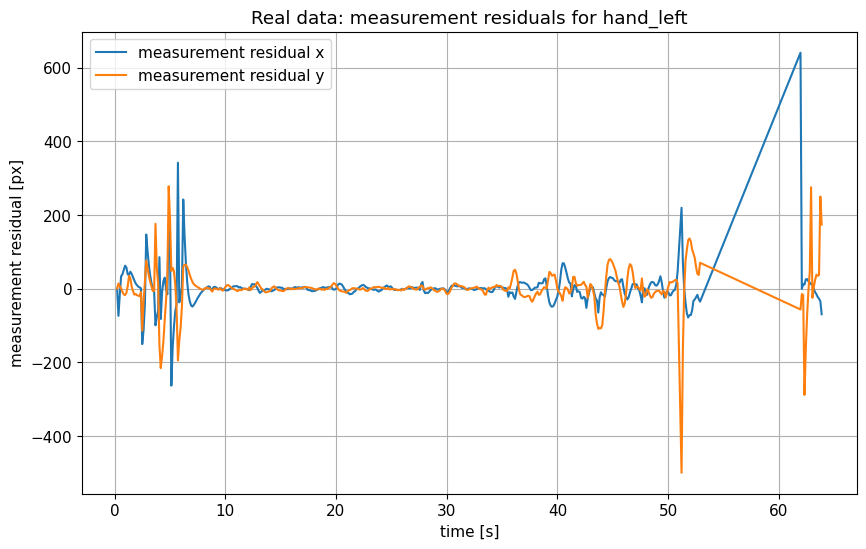

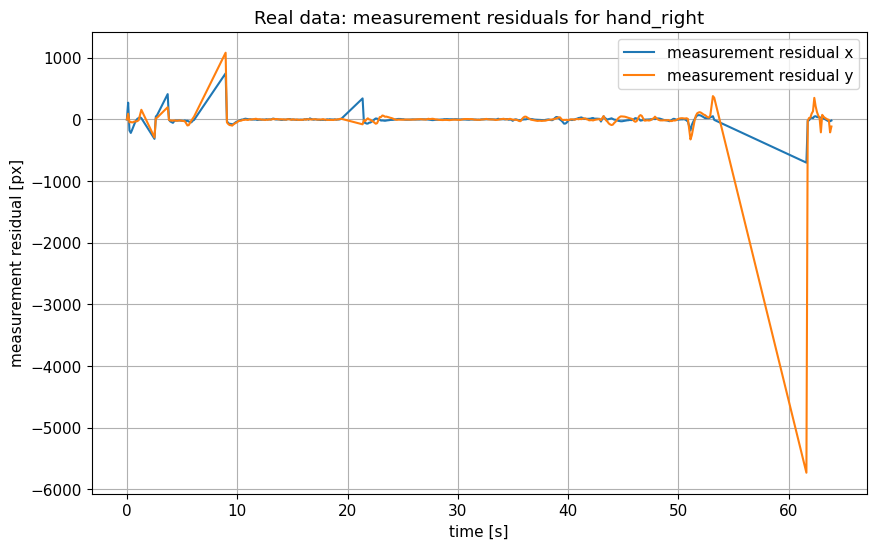

In [129]:
for obj, result in real_results.items():
    plt.figure(figsize=(10, 6))
    plt.plot(result["time"], result["residual_x"], label="measurement residual x")
    plt.plot(result["time"], result["residual_y"], label="measurement residual y")
    plt.xlabel("time [s]")
    plt.ylabel("measurement residual [px]")
    plt.title(f"Real data: measurement residuals for {obj}")
    plt.legend()
    plt.show()

## 7. Multi-step prediction

Multi-step prediction shows what the filter expects in the future if it does not receive any additional measurements. In each future step, only the motion model and the process covariance matrix are used. The correction step is not performed because no new observation is available.

This part is important for interpreting uncertainty. The predicted mean continues according to the estimated position and velocity, but the uncertainty intervals gradually become wider. This matches intuition: the further into the future we predict without new measurements, the less certain the resulting estimate becomes.

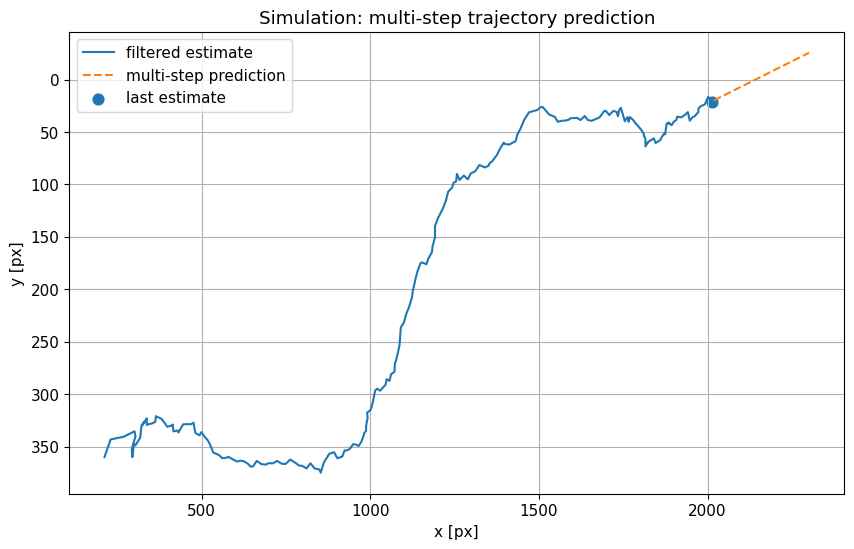

In [130]:
def predict_future(last_state, last_covariance, dt, steps, sigma_a):
    states = []
    covs = []
    mu = last_state.copy()
    Sigma = last_covariance.copy()

    for _ in range(steps):
        A = A_matrix(dt)
        Q = Q_matrix(dt, sigma_a)
        mu = A @ mu
        Sigma = A @ Sigma @ A.T + Q
        states.append(mu.copy())
        covs.append(Sigma.copy())

    return np.array(states), np.array(covs)

last_state = sim_filter[["x", "y", "vx", "vy"]].iloc[-1].to_numpy()
last_cov = sim_covs[-1]
dt_future = float(np.median(np.diff(sim_df["time"])))
future_steps = 40
future_states, future_covs = predict_future(last_state, last_cov, dt_future, future_steps, sigma_a_sim)
future_times = sim_df["time"].iloc[-1] + np.arange(1, future_steps + 1) * dt_future
future_std_x = np.sqrt(future_covs[:, 0, 0])
future_std_y = np.sqrt(future_covs[:, 1, 1])

plt.figure(figsize=(10, 6))
plt.plot(sim_filter["x"], sim_filter["y"], label="filtered estimate")
plt.plot(future_states[:, 0], future_states[:, 1], linestyle="--", label="multi-step prediction")
plt.scatter(sim_filter["x"].iloc[-1], sim_filter["y"].iloc[-1], s=60, label="last estimate")
plt.xlabel("x [px]")
plt.ylabel("y [px]")
plt.title("Simulation: multi-step trajectory prediction")
plt.legend()
plt.gca().invert_yaxis()
plt.show()

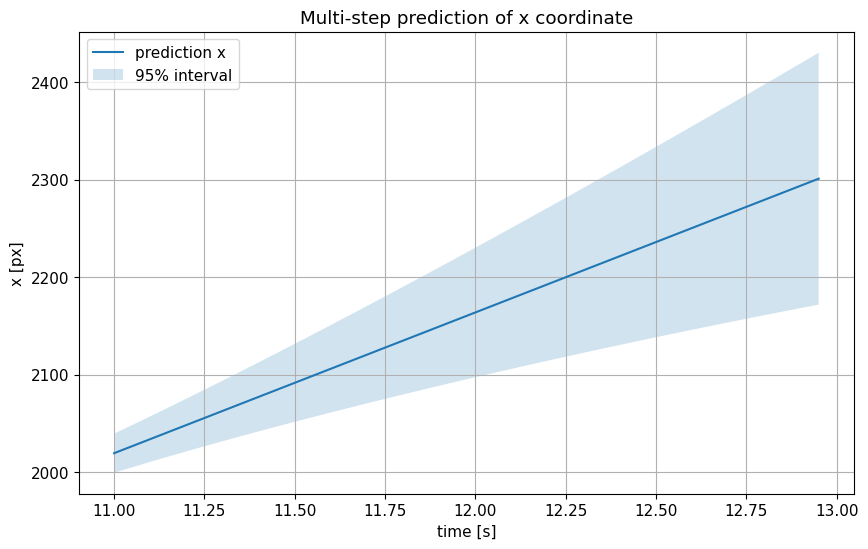

In [131]:
plt.figure(figsize=(10, 6))
plt.plot(future_times, future_states[:, 0], label="prediction x")
plt.fill_between(future_times, future_states[:, 0] - 1.96*future_std_x, future_states[:, 0] + 1.96*future_std_x, alpha=0.20, label="95% interval")
plt.xlabel("time [s]")
plt.ylabel("x [px]")
plt.title("Multi-step prediction of x coordinate")
plt.legend()
plt.show()

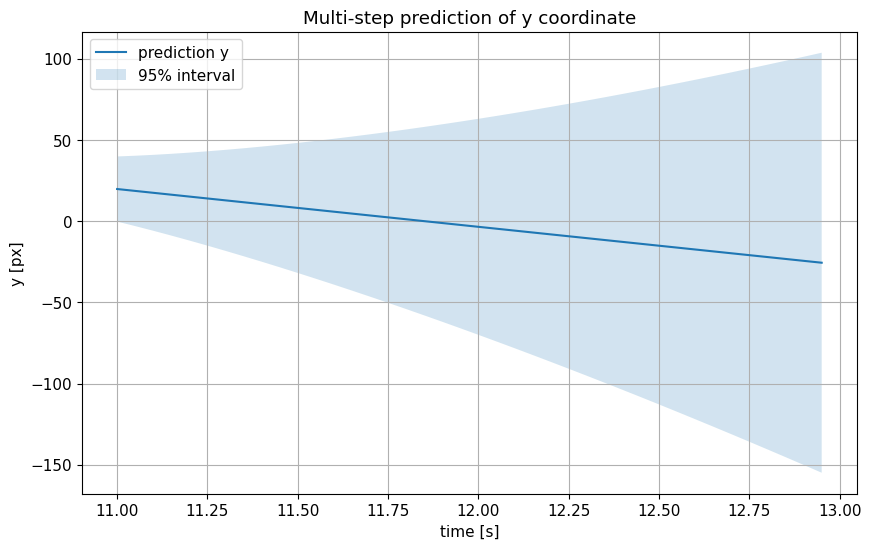

In [132]:
plt.figure(figsize=(10, 6))
plt.plot(future_times, future_states[:, 1], label="prediction y")
plt.fill_between(future_times, future_states[:, 1] - 1.96*future_std_y, future_states[:, 1] + 1.96*future_std_y, alpha=0.20, label="95% interval")
plt.xlabel("time [s]")
plt.ylabel("y [px]")
plt.title("Multi-step prediction of y coordinate")
plt.legend()
plt.show()

## 8. Influence of parameters

The most important model parameters are $\sigma_z$ and $\sigma_a$.

The parameter $\sigma_z$ describes measurement uncertainty. If $\sigma_z$ is large, the filter assumes that the detector is inaccurate and therefore relies more on the motion model. The result is a smoother estimate, but also a slower reaction to rapid changes. If $\sigma_z$ is small, the filter trusts the measurements more and the estimate becomes closer to the measured points.

The parameter $\sigma_a$ describes uncertainty in the motion model. A small $\sigma_a$ means that the filter strongly enforces the constant-velocity model. A large $\sigma_a$ allows faster changes in motion, for example stronger hand acceleration or a change of direction.

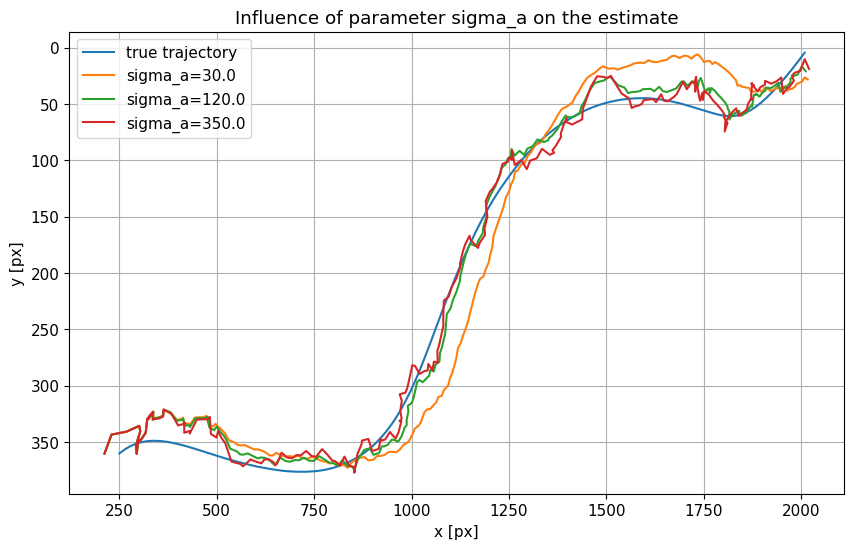

,sigma_a,RMSE x,RMSE y
0,30.0,21.933093,25.404886
1,120.0,11.834460,13.301396
2,350.0,10.637023,13.082341


In [133]:
rows = []
plt.figure(figsize=(10, 6))
plt.plot(sim_df["true_x"], sim_df["true_y"], label="true trajectory")

for sigma_a_test in [30.0, 120.0, 350.0]:
    result, _ = run_kalman_filter(
        sim_df["time"].to_numpy(),
        sim_df[["meas_x", "meas_y"]].to_numpy(),
        sigma_a=sigma_a_test,
        sigma_z=sigma_z_sim,
    )
    plt.plot(result["x"], result["y"], label=f"sigma_a={sigma_a_test}")
    rows.append({
        "sigma_a": sigma_a_test,
        "RMSE x": rmse(result["x"], truth_x),
        "RMSE y": rmse(result["y"], truth_y),
    })

plt.xlabel("x [px]")
plt.ylabel("y [px]")
plt.title("Influence of parameter sigma_a on the estimate")
plt.legend()
plt.gca().invert_yaxis()
plt.show()

pd.DataFrame(rows)

## 9. Conclusion

The project showed that hand motion in a video sequence can be represented by a simple discrete linear state-space model. Even though the model assumes approximately constant velocity, the added process noise makes it flexible enough to describe natural changes in hand movement between frames. The state vector contains both position and velocity components, while the detector provides only noisy position measurements. Therefore, the velocity has to be estimated indirectly from the sequence of observed positions.

On simulated data, the Kalman filter was able to combine the motion model with noisy measurements and produce a smoother estimate of the true trajectory. The comparison with the known true state showed that the filtered estimate follows the real motion more consistently than the raw measurements. This demonstrates that the method does not only smooth the observed data, but also estimates the hidden components of the state vector, especially the velocity.

The uncertainty intervals showed how the reliability of the estimate changes over time. At the beginning, the uncertainty is higher because only a small amount of information is available. After several measurements, the filter becomes more certain and the intervals usually become narrower. When predictions are made without additional measurements, the uncertainty grows again, which correctly reflects the fact that future motion becomes less certain without new observations.

The real-data experiment showed that the same approach can be applied to hand measurements obtained from a webcam. The detector script provides measured hand centers, while the Kalman filter in the notebook processes these measurements and estimates the underlying state. The quality of the final estimate depends on the quality of the detector, but the filter is still useful for reducing measurement noise and for bridging short gaps or irregularities in the data.

Overall, the project demonstrated that the Kalman filter is suitable for tracking hand position in a video sequence when the measurements are noisy and only part of the state is directly observed. The method provides not only filtered position estimates, but also velocity estimates, uncertainty intervals, and multi-step predictions, which makes it useful for analysing dynamic systems with uncertainty.